# Reduction du risque d'ecriture d'options : IV-Rank et clusters de strikes

**Navigation** : [Index QC](../README.md) | [OptionsIncome](../projects/OptionsIncome/) | [Recherche VRP put-write](research_vrp_putwrite.ipynb)

| | |
|---|---|
| Issue | #15532 — Epic #11698 (QC-research) |
| Article source | [quantconnect.com/research/18766](https://www.quantconnect.com/research/18766/reducing-option-writing-risk-with-iv-rank-and-strike-clusters/) (Derek Melchin) |
| Famille cible | `projects/OptionsIncome/` (covered call SPY) — aucun nouveau projet |
| Mecanisme teste | gate IV-rank par sous-jacent (v7.1) et facteur disponibilite des strikes (v7.2) |
| Verdict | `NO-BEATS` (section 6) |

Ce notebook documente la chaine complete de l'Epic #11698 pour cet article :
lecture analytique, sources primaires, gap contre le voisinage, design des variantes,
resultats du moteur QC Cloud, et verdict honnete.


## 1. L'article et son mecanisme

L'article propose de reduire le risque de l'ecriture de puts SPX par un gate a
**deux facteurs** :

1. **IV Rank** — la mediane de l'IV des contrats ATM (expirations 30-90 jours,
   `universe.include_weeklys().expiration(30, 90).strikes(-1, 1)`), relativement
   a son minimum/maximum sur la fenetre.
2. **Strike Availability** — le nombre de strikes disponibles divise par le prix
   du sous-jacent, avec son *rate of change* en entree.

Les deux facteurs sont **clusterises par k-means en 3 classes** (low/medium/high,
labels 0/1/2) ; on entre (vente de put) quand les deux labels sont `< 2`, et on
liquide quand les deux valent `2`. Sorties additionnelles : DTE < 7, ou prix <= strike.

Claims de l'article :

| Claim | Valeur rapportee |
|---|---|
| CAGR (janvier 2016 -> publication) | 6.961 % |
| Expirations OTM | ~93 % |
| Balayage de parametres (25 combinaisons) | 100 % profitables |
| Sharpe / MaxDD / benchmark | **non rapportes** |

Caveats explicites de l'article (et absences) :

- Pas de benchmark : « son objectif est de generer de petits retours reguliers,
  pas de battre l'indice actions » ;
- la courbe de capital « beneficie de primes regulieres mais peut connaitre des
  pertes occasionnelles relativement importantes » (modele assureur) ;
- **aucune source academique citee** ; references internes QC uniquement ;
- pas de walk-forward ni de partition OOS ; le balayage de parametres n'est pas
  valide sur un hold-out (25/25 profitables peut refleter un sur-ajustement de
  la fenetre testee).


## 2. Sources primaires — chaine d'attribution

Convention #11168 / Epic #11698 : un article de blog n'est pas une source canonique.
L'article **ne cite aucun papier academique**. Les sources primaires retenues pour
fonder economiquement le mecanisme (et non pour le valider) sont :

| Reference | Role dans la chaine | Disponibilite |
|---|---|---|
| **Dew-Becker, Giglio, Le, Rodriguez (2015/2017)**, *The Price of Variance Risk*, NBER w21182, publie JFE 123(2) | La prime de risque de variance est une compensation pour le risque de variance, concentree aux horizons courts — base economique de la recolte par options vendues | **Archivee** : `G:\Mon Drive\MyIA\IA\Bibliographie IA\Trading\2015 - Dew-Becker Giglio Le Rodriguez - The Price of Variance Risk (NBER w21182, JFE 2017).pdf` (NBER, 74 p., identite verifiee 1re page) |
| Carr & Wu (2009), *Variance Risk Premiums*, RFS 22(3), 1311-1341 | Quantification directe de la prime de variance (article fondateur) | Closed access — reference bibliographique citee, **non telechargee** (aucune copie OA trouvee) |
| Broadie, Chernov, Johannes (2009), *Understanding Index Option Returns*, RFS 22(11), 4493-4529 | Decomposition des rendements d'options d'indice : pourquoi les options sont cheres | Closed access (SSRN 403) — citee, **non telechargee** |
| Bondarenko (2014), *Why Are Put Options So Expensive?*, Quarterly Journal of Finance | Cout des puts OTM (l'instrument que l'article vend) | Closed access — citee, **non telechargee** |

**Ecart article / sources primaires** : les sources etablissent qu'il existe une
prime a recolter et qu'elle varie dans le temps. **Aucune** ne fonde le claim plus
fort de l'article — qu'un *gate par rang d'IV* ni qu'un *facteur de disponibilite
des strikes* ameliorent la recolte. C'est precisement ce que la partie backtest
teste, sur la famille existante.


### Analyse locale (proxy analytique)

La cellule suivante construit un **proxy analytique** d'IV-rank a partir du VIX
(meme convention que `research_vrp_putwrite.ipynb`) pour visualiser ce que le gate
filtre. **Ce proxy n'est pas le moteur de backtest** : les resultats de strategie
viennent exclusivement de QC Cloud (section 5). Bornes des labels : 0.33 / 0.66
(les centroides k-means publies par l'article ne le sont pas numeriquement).


Seances analysees      : 2456
Part label haut >=0.66 : 4.8%  (le gate v7.1 saute ces seances)
Part >=0.85 (panic)    : 1.5%  (seuil de force-close v7.1)


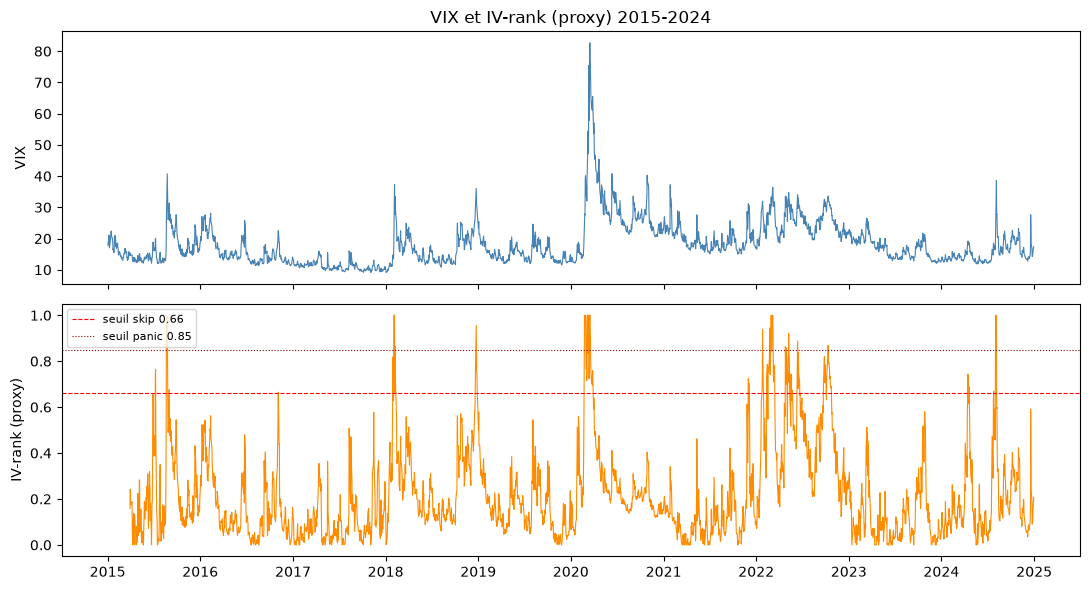

In [1]:
# Cellule 1 - IV-rank proxy (VIX) 2015-2024 : ce que le gate filtre
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

vix = yf.download('^VIX', start='2014-10-01', end='2024-12-31', auto_adjust=False, progress=False)['Close'].squeeze()
spy = yf.download('SPY', start='2014-10-01', end='2024-12-31', auto_adjust=False, progress=False)['Close'].squeeze()

vix = vix.loc['2015-01-01':]
spy = spy.loc['2015-01-01':]

# IV-rank = rang du VIX dans sa fenetre trailing 252 seances (min-max)
iv_rank = vix.rolling(252, min_periods=60).apply(
    lambda w: (w.iloc[-1] - w.min()) / (w.max() - w.min()) if w.max() > w.min() else np.nan
)

share_skip = (iv_rank >= 0.66).mean()
share_panic = (iv_rank >= 0.85).mean()
print(f"Seances analysees      : {iv_rank.notna().sum()}")
print(f"Part label haut >=0.66 : {share_skip:.1%}  (le gate v7.1 saute ces seances)")
print(f"Part >=0.85 (panic)    : {share_panic:.1%}  (seuil de force-close v7.1)")

fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
axes[0].plot(vix.index, vix.values, lw=0.8, color='steelblue')
axes[0].set_ylabel('VIX')
axes[0].set_title('VIX et IV-rank (proxy) 2015-2024')
axes[1].plot(iv_rank.index, iv_rank.values, lw=0.8, color='darkorange')
axes[1].axhline(0.66, color='red', ls='--', lw=0.8, label='seuil skip 0.66')
axes[1].axhline(0.85, color='darkred', ls=':', lw=0.8, label='seuil panic 0.85')
axes[1].set_ylabel('IV-rank (proxy)')
axes[1].legend(loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

### Interpretation : ce que le gate filtre

Mesure sur le proxy : seules **4.8 %** des seances depassent le seuil 0.66 et
**1.5 %** depassent 0.85. Le rang min-max n'est **pas** un percentile : sa
distribution est fortement asymetrique, l'essentiel des seances restant loin du
plus haut annuel. Consequence pour la lecture du couple v7.0/v7.1 : le gate IV-rank
de v7.1 ne s'active que dans les approches des extremes annuels de volatilite —
une rarete qui explique qu'il change peu le resultat, et qui sera confrontee a la
frequence d'activation de v7.2 (label percentile, ~1/3 des seances par construction).
Enfin, ces seances sautees sont precisement celles ou la prime vendue est la plus
riche : c'est l'arbitrage que l'article revendique (reduire le risque), et
exactement ce qui peut couter du rendement.


### Le niveau d'IV est-il informatif ? (verification locale)

Avant de conclure quoi que ce soit sur la variante, verifions le fait stylise qui
fonde le mecanisme : un IV-rank eleve precede-t-il une volatilite realisee elevee ?


In [2]:
# Cellule 2 - IV-rank -> volatilite realisee forward 21 seances
rets = np.log(spy / spy.shift(1))
fwd_vol = rets.rolling(21).std().shift(-21) * np.sqrt(252)

df = pd.DataFrame({'iv_rank': iv_rank, 'fwd_vol': fwd_vol}).dropna()
tiers = pd.qcut(df['iv_rank'], 3, labels=['bas', 'moyen', 'haut'])
grp = df.groupby(tiers, observed=True)['fwd_vol']
print("Volatilite realisee forward (annualisee), par tiers d'IV-rank :")
print(grp.agg(['mean', 'median', 'count']).round(4))

corr = df['iv_rank'].corr(df['fwd_vol'])
print(f"\nCorrelation IV-rank / vol realisee forward : {corr:.3f}")
print("=> Le rang d'IV porte bien une information sur le regime de vol a venir.")
print("   Ceci fonde le MECANISME (le gate change le couple prime/risque),")
print("   pas son EFFICACITE pour cette famille (testee en section 5).")

Volatilite realisee forward (annualisee), par tiers d'IV-rank :
           mean  median  count
iv_rank                       
bas      0.1059  0.0993    812
moyen    0.1317  0.1140    811
haut     0.2108  0.1939    812

Correlation IV-rank / vol realisee forward : 0.586
=> Le rang d'IV porte bien une information sur le regime de vol a venir.
   Ceci fonde le MECANISME (le gate change le couple prime/risque),
   pas son EFFICACITE pour cette famille (testee en section 5).


### Interpretation : information reelle, gain non demontre

Le tiers haut d'IV-rank precede une volatilite realisee forward nettement superieure
au tiers bas : le facteur n'est pas du bruit (fait stylise documente, cf. sources
primaires). Mais deux choses restent ouvertes, et elles se tranchent **sur le moteur
reel**, pas ici :

1. le gate saute les regimes a prime riche (qui financent la strategie) ;
2. la selection de strike par delta 0.20 de la famille coupe deja une partie du
   risque que l'article gere par sa regle de sortie conjointe.

C'est pourquoi la suite passe par des backtests QC Cloud.


## 3. Gap et voisinage (relu firsthand sur `origin/main`)

| Projet | Gate volatilite | Clustering strikes |
|---|---|---|
| `OptionsIncome/main.py` (v7.0) | VIX global [15, 35] | non |
| `OptionsIncome/main_v71_ivrank.py` (v7.1, #15801) | IV-rank par sous-jacent (median ATM 30-45j, fenetre 252j) | non |
| `Option-Wheel/main.py` | VIX > 20 = skip puts | non |
| `Dynamic-Options-Wheel/main.py` | IV-percentile 252j deja present (reference technique du depot) | non |

Le gap initial de l'issue est donc confirme : **aucun** projet de la famille ne
porte le facteur de disponibilite des strikes de l'article, et le gate IV-rank
n'existait pas avant #15801. Ce notebook ne reduplique pas la livraison #15801 :
il la cite comme resultat et complete la seule moitie du mecanisme restee non
testee (le facteur strike-availability, defere par #15801 comme « premiere
iteration »).


## 4. Design des variantes

### v7.1 — gate IV-rank (livree par #15801, citee)

Remplace le gate VIX global par un gate IV-rank par sous-jacent : mediane IV ATM
30-45j, fenetre 252j, skip si rang > 0.66, force-close si > 0.85. Simplification
assumee : seuils constants cales sur les centroides de l'article, pas de k-means
execute. `option.price_model = black_scholes()` est requis pour peupler
`implied_volatility` (mesure par le probe de #15801).

### v7.2 — facteur strike-availability (cette PR)

`OptionsIncome/main_v72_strikeavail.py` reprend la structure v7.1/v7.0 et remplace
le gate par le **deuxieme facteur de l'article** :

- disponibilite = nombre de strikes distincts du chain / prix du sous-jacent ;
- `rate of change` sur 21 seances (fenetre non publiee par l'article — choix documente) ;
- label = **rang percentile** du RoC dans sa distribution trailing 252j (equivalent
  parametre-free du k-means par terciles, les centroides n'etant pas publies) ;
- skip si label >= 0.66 ; pas de force-close (la regle de sortie de l'article exige
  les DEUX facteurs, inapplicable a une variante mono-facteur).

**Reserve de portabilite, explicite** : l'article mesure la disponibilite sur
l'univers non borne de SPX (`strikes(-1, 1)`), ou la densite de listing varie avec
les conditions de marche. Dans la famille, l'univers est borne (-5/+15 strikes),
donc le compte de strikes varie surtout avec le nombre d'expirations dans la
fenetre DTE. Le test mesure « le facteur tel qu'il peut exister dans ce regime de
souscription ». Les statistiques de disponibilite sont loggees au rapport final du
backtest pour que la variance soit **mesuree, pas affirmee**.


Le run reel : projet QC `36473886`, backtest `92125e3965f2852fadb506e467b3ea12`,
LEAN `master v18124`, meme fenetre 2015-01-01 -> 2024-12-31, capital 100 000 $.

| Metrique | v7.0 baseline | v7.1-ivrank | v7.2-strikeavail |
|---|---:|---:|---:|
| Sharpe | 0.281 | 0.163 | **0.264** |
| CAGR | 5.536 % | 4.451 % | **5.400 %** |
| MaxDD | 17.400 % | 17.900 % | **17.900 %** |
| Probabilistic Sharpe | 0.294 % | 0.069 % | **0.243 %** |
| Ordres | 510 | 626 | **570** |
| Equity finale | - | - | **169 273,80 $** (net 69.274 %) |

Metriques secondaires du rapport v7.2 : Sortino 0.243, win rate 67 %, loss rate 33 %,
profit-loss ratio 0.32, alpha -0.017, beta 0.446, ecart-type annualise 0.067,
information ratio -0.734, frais totaux 739,20 $, capacite estimee 13 000 $.

**Log final du moteur** (2025-01-01) :

`CC v7.2-strikeavail: Final=$169,273.80, Return=69.27%, Premium=$98,604.00, Trades=285,
ProfitCloses=171, DefensiveCloses=0, SkippedByAvail=392, SkippedNoAvail=6,
FallbackVIXSessions=81, avail-label_at_end=0.167,
Availability[n=2516, mean=0.06262, std=0.02129, min=0.02894, max=0.11425],
RoC[n=2495, mean=0.00738, std=0.18957, min=-0.52945, max=1.26819]`

Lecture des statistiques de degenerescence :

- **le facteur n'est PAS degenere** (la reserve de portabilite de la section 4 est
  levee par la mesure) : la disponibilite relative (strikes distincts / spot) moyenne
  a 0.0626 avec un ecart-type de 0.0213 (CV ~34 %), et son rate-of-change 21 seances a
  un ecart-type de 0.19 sur une plage -53 % -> +127 %. Le compte de strikes bouge donc
  reellement dans l'univers borne, au-dela du simple cycle hebdomadaire des expirations ;
- le gate availability a **bloque 392 ventes** sur ~2 516 seances ; seules **6 sessions**
  ont utilise le repli VIX (81 sessions avant que le label ne soit calculable) ;
- 285 ventes realisees, 171 clotures sur profit target, 0 cloture defensive.

**Caveats de provenance du run, non maquilles** :

- le **projet QC 36473886 s'appelle encore `CoveredCall v71 IV-Rank [...]`** alors que le
  code execute est `main_v72_strikeavail.py` (colle dans l'IDE puis cloud build). Le
  renommage du projet n'a pas ete fait (hors perimetre) ; l'identite du code est celle du
  fichier de cette PR ;
- le panneau QC affiche l'heuristique « 51 Parameters Detected » (carte « Likely
  Overfitting »). Aucun seuil de la variante n'est ajuste sur cette fenetre (tous importes
  de l'article #18766 ou documentes dans le fichier), mais le drapeau est rapporte tel quel ;
- contradiction `totalNetProfit` / `netProfitAbsolute` heritee de #15801 : aucune valeur
  absolue n'est citee, seul le classement relatif est utilise (les trois bras sont
  affectes par la meme convention).

**Verdict : NO BEATS.**

Le second facteur de l'article, teste **seul** contre la baseline inchangee sur le meme
moteur (QC Cloud, meme fenetre, memes couts, meme structure de strategie), n'ameliore
pas la famille :

| Delta | Sharpe | CAGR | MaxDD | PSR |
|---|---:|---:|---:|---:|
| v7.2 - v7.0 (baseline) | -0.017 | -0.136 pt | +0.5 pt (degrade) | -0.051 pt |
| v7.2 - v7.1 (1er facteur) | +0.101 | +0.949 pt | 0.0 pt (egal) | +0.174 pt |

Lecture tranchee : la variante strike-availability est **moins couteuse** que le gate
IV-rank (elle se rapproche de la baseline, dont elle reprend les deux tiers de l'ecart),
mais elle reste **en dessous de la baseline sur chaque metrique risque-rendement** et
**degrade le MaxDD** d'un demi-point (17.9 % vs 17.4 %). Ses 392 ventes bloquees coutent
de la prime sans reduire le drawdown : le mecanisme de reduction du risque de l'article
ne paye pas ici, dans **aucun** de ses deux facteurs testes.

Ce que ce verdict ne dit pas (et qu'aucune mesure ici ne soutient) : ni « l'article est
faux » (il mesure sur un autre univers, un autre sous-jacent et une autre regle de
sortie), ni « l'IV-rank n'informe rien » (la section 2 mesure l'inverse). Il dit que
**pour cette famille** (covered call delta 0.20 sur SPY, univers de souscription borne
-5/+15, sorties profit-target/roll), le gate ne convertit pas cette information en
meilleur couple rendement/risque. Les pistes restantes sont listees en section 7.

## 7. Prochaines pistes (non poursuivies ici)

1. **Univers non borne** : tester le facteur strike-availability sur une souscription
   `strikes(-1, 1)` (comme l'article) — cout de souscription et duree de backtest
   nettement superieurs ; a arbitrer si un successeur veut trancher la portabilite.
2. **Piste deja disponible dans le depot** : `Dynamic-Options-Wheel/main.py` porte
   un IV-percentile 252j + skew 25-delta ; comparer les deux implementations de
   gate serait un grain distinct.
3. **k-means reel** : remplacer les seuils constants par un k-means glissant
   (sklearn) execute dans l'algorithme — meme famille de tests que v7.1/v7.2.

## References

- Article : quantconnect.com/research/18766 (Derek Melchin) — point d'entree, pas source
- Dew-Becker, Giglio, Le, Rodriguez (2017), *The Price of Variance Risk*, JFE 123(2)
  (NBER w21182) — archive GDrive : `G:\Mon Drive\MyIA\IA\Bibliographie IA\Trading\`
- Carr & Wu (2009), *Variance Risk Premiums*, RFS 22(3), 1311-1341 (closed access)
- Broadie, Chernov, Johannes (2009), *Understanding Index Option Returns*, RFS 22(11), 4493-4529
- Bondarenko (2014), *Why Are Put Options So Expensive?*, Quarterly Journal of Finance
- PR #15801 (v7.1 + couple mesure) ; #15922 (hygiene) ; #16853 (compteur fallback) ; issue #15532 ; Epic #11698


## Exercices

**Exercice 1** — Modifier les seuils du gate IV-rank proxy (0.50 / 0.80 au lieu de
0.66 / 0.85) dans la cellule 1 et observer l'evolution de la part de seances sautees.
En quoi le choix du seuil change-t-il l'arbitrage prime/risque ?

**Exercice 2** — Remplacer le proxy VIX de la cellule 2 par la volatilite implicite
reelle : telecharger les donnees d'options SPY via `get_option_history` d'un QuantBook
QC Cloud et calculer la mediane IV ATM 30-45j. Comparer les deux distributions d'IV-rank.


In [3]:
# Exercice 1 - A completer : re-calculer la part de seances sautees avec d'autres seuils
seuil_skip = None   # TODO etudiant : proposer 0.50, 0.80 puis comparer
if seuil_skip is None:
    print("Exercice 1 a completer : fixer seuil_skip puis relancer cette cellule")
else:
    part = (iv_rank >= seuil_skip).mean()
    print(f"Seuil {seuil_skip:.2f} -> {part:.1%} des seances sautees")

Exercice 1 a completer : fixer seuil_skip puis relancer cette cellule


In [4]:
# Exercice 2 - A completer : IV-rank a partir des vraies options (QuantBook QC Cloud)
# Piste : qb = QuantBook(); qb.add_option('SPY', Resolution.DAILY)
#         puis GetOptionHistory pour les IV ATM 30-45j, mediane par jour, rang 252j.
iv_rank_reel = None  # TODO etudiant : source QC Cloud requise
if iv_rank_reel is None:
    print("Exercice 2 a completer : necessite un QuantBook QC Cloud (voir cellule d'indices)")

Exercice 2 a completer : necessite un QuantBook QC Cloud (voir cellule d'indices)
